# NHS A&E Pressure Dashboard

## Project overview

This project analyses publicly available NHS A&E attendance and emergency admission data to identify pressure points across providers and regions.

The aim is to demonstrate how public healthcare data can be cleaned, analysed and turned into useful operational insights.

## Business/public-sector problem

A&E departments face pressure from high attendance volumes, emergency admissions, long waits and delays after decisions to admit. By analysing public A&E data, we can identify which providers are under the most pressure, compare performance, and highlight areas that may need operational attention.

## Skills demonstrated

- Data cleaning
- Exploratory data analysis
- KPI creation
- Provider ranking
- Trend analysis
- Outlier detection
- Data visualisation
- Business insight reporting

## Data source

NHS England public A&E Attendances and Emergency Admissions data.

##1. Importing the tools

I start by importing the main Python libraries needed for the project. Pandas is used for working with the dataset, NumPy helps with numerical operations, and Matplotlib is used to create simple charts.

In [96]:
# Core libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")


Libraries imported successfully.


##2. Loading the data

In this step, I load the public NHS A&E dataset into the notebook so it can be cleaned, explored and analysed.

For this project, I am using publicly available NHS England A&E attendance and emergency admissions data. The dataset includes provider-level information on A&E attendances, emergency admissions, four-hour performance and waits after a decision to admit.

In [97]:
from google.colab import drive
drive.mount('/content/drive')

folder_path = "/content/drive/MyDrive/ClearCell Data Portfolio/01_NHS_AE_Pressure_Dashboard"

import os

os.listdir(folder_path)

files = {
    "2025-10": "ae_2025_10.csv",
    "2025-11": "ae_2025_11.csv",
    "2025-12": "ae_2025_12.csv",
    "2026-01": "ae_2026_01.csv",
    "2026-02": "ae_2026_02.csv",
    "2026-03": "ae_2026_03.csv"
}

# Load each file and add a month column

dataframes = []

for month, file_name in files.items():
    file_path = os.path.join(folder_path, file_name)
    temp_df = pd.read_csv(file_path)
    temp_df["month"] = month
    dataframes.append(temp_df)

# Combine all months into one dataset

df = pd.concat(dataframes, ignore_index=True)

# Preview the combined data

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Period,Org Code,Parent Org,Org name,A&E attendances Type 1,A&E attendances Type 2,A&E attendances Other A&E Department,A&E attendances Booked Appointments Type 1,A&E attendances Booked Appointments Type 2,A&E attendances Booked Appointments Other Department,Attendances over 4hrs Type 1,Attendances over 4hrs Type 2,Attendances over 4hrs Other Department,Attendances over 4hrs Booked Appointments Type 1,Attendances over 4hrs Booked Appointments Type 2,Attendances over 4hrs Booked Appointments Other Department,Patients who have waited 4-12 hs from DTA to admission,Patients who have waited 12+ hrs from DTA to admission,Emergency admissions via A&E - Type 1,Emergency admissions via A&E - Type 2,Emergency admissions via A&E - Other A&E department,Other emergency admissions,month
0,MSitAE-OCTOBER-2025,RAN,NHS ENGLAND LONDON,ROYAL NATIONAL ORTHOPAEDIC HOSPITAL NHS TRUST,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,24,2025-10
1,MSitAE-OCTOBER-2025,RBQ,NHS ENGLAND NORTH WEST,LIVERPOOL HEART AND CHEST HOSPITAL NHS FOUNDAT...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,172,2025-10
2,MSitAE-OCTOBER-2025,RLQ,NHS ENGLAND MIDLANDS,WYE VALLEY NHS TRUST,6138,1143,127,107,0,0,2478,0,0,28,0,0,417,272,1495,0,0,172,2025-10
3,MSitAE-OCTOBER-2025,RYY,NHS ENGLAND SOUTH EAST,KENT COMMUNITY HEALTH NHS FOUNDATION TRUST,0,0,6140,0,0,0,0,0,13,0,0,0,0,0,0,0,0,0,2025-10
4,MSitAE-OCTOBER-2025,AAH,NHS ENGLAND SOUTH WEST,TETBURY HOSPITAL TRUST LTD,0,0,609,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2025-10


##3. First look at the dataset

Before doing any analysis, I take an initial look at the data to understand the columns, structure, data types and any obvious issues that may need cleaning.

In [98]:
# Check the size of the combined dataset

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


# View the column names

df.columns


# Preview the first few rows

df.head()


#listing the column names

df.columns

Rows: 1190
Columns: 23


Index(['Period', 'Org Code', 'Parent Org', 'Org name',
       'A&E attendances Type 1', 'A&E attendances Type 2',
       'A&E attendances Other A&E Department',
       'A&E attendances Booked Appointments Type 1',
       'A&E attendances Booked Appointments Type 2',
       'A&E attendances Booked Appointments Other Department',
       'Attendances over 4hrs Type 1', 'Attendances over 4hrs Type 2',
       'Attendances over 4hrs Other Department',
       'Attendances over 4hrs Booked Appointments Type 1',
       'Attendances over 4hrs Booked Appointments Type 2',
       'Attendances over 4hrs Booked Appointments Other Department',
       'Patients who have waited 4-12 hs from DTA to admission',
       'Patients who have waited 12+ hrs from DTA to admission',
       'Emergency admissions via A&E - Type 1',
       'Emergency admissions via A&E - Type 2',
       'Emergency admissions via A&E - Other A&E department',
       'Other emergency admissions', 'month'],
      dtype='object')

## 4. Cleaning the data

This step prepares the dataset for analysis by checking for missing values, cleaning column names, removing unnecessary fields and making sure the key numbers are in the correct format.

The raw dataset contains separate columns for different A&E department types. To make the analysis easier to interpret, I create combined totals for attendances, waits over 4 hours, emergency admissions and long waits after a decision to admit.

In [99]:
# Create a clean working copy

ae = df.copy()

# Clean column names safely
ae.columns = (
    ae.columns
    .str.strip()
    .str.lower()
    .str.replace("&", "and", regex=False)
    .str.replace("+", "plus", regex=False)
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)

# View cleaned column names
ae.columns.tolist()

['period',
 'org_code',
 'parent_org',
 'org_name',
 'aande_attendances_type_1',
 'aande_attendances_type_2',
 'aande_attendances_other_aande_department',
 'aande_attendances_booked_appointments_type_1',
 'aande_attendances_booked_appointments_type_2',
 'aande_attendances_booked_appointments_other_department',
 'attendances_over_4hrs_type_1',
 'attendances_over_4hrs_type_2',
 'attendances_over_4hrs_other_department',
 'attendances_over_4hrs_booked_appointments_type_1',
 'attendances_over_4hrs_booked_appointments_type_2',
 'attendances_over_4hrs_booked_appointments_other_department',
 'patients_who_have_waited_4_12_hs_from_dta_to_admission',
 'patients_who_have_waited_12plus_hrs_from_dta_to_admission',
 'emergency_admissions_via_aande_type_1',
 'emergency_admissions_via_aande_type_2',
 'emergency_admissions_via_aande_other_aande_department',
 'other_emergency_admissions',
 'month']

In [100]:
# Show exact cleaned column names

for col in ae.columns:
    print(col)

period
org_code
parent_org
org_name
aande_attendances_type_1
aande_attendances_type_2
aande_attendances_other_aande_department
aande_attendances_booked_appointments_type_1
aande_attendances_booked_appointments_type_2
aande_attendances_booked_appointments_other_department
attendances_over_4hrs_type_1
attendances_over_4hrs_type_2
attendances_over_4hrs_other_department
attendances_over_4hrs_booked_appointments_type_1
attendances_over_4hrs_booked_appointments_type_2
attendances_over_4hrs_booked_appointments_other_department
patients_who_have_waited_4_12_hs_from_dta_to_admission
patients_who_have_waited_12plus_hrs_from_dta_to_admission
emergency_admissions_via_aande_type_1
emergency_admissions_via_aande_type_2
emergency_admissions_via_aande_other_aande_department
other_emergency_admissions
month


In [101]:
# Helper function to find columns containing keywords

def find_cols(include_keywords, exclude_keywords=None):
    if exclude_keywords is None:
        exclude_keywords = []

    matched_cols = []

    for col in ae.columns:
        col_lower = col.lower()

        if all(keyword in col_lower for keyword in include_keywords):
            if not any(exclude in col_lower for exclude in exclude_keywords):
                matched_cols.append(col)

    return matched_cols


# Find attendance columns

attendance_cols = find_cols(
    ["attendances"],
    exclude_keywords=["booked", "over"]
)

over_4hr_cols = find_cols(
    ["attendances", "over_4hrs"],
    exclude_keywords=["booked"]
)

booked_cols = find_cols(
    ["booked", "appointments"],
    exclude_keywords=["over"]
)

booked_over_4hr_cols = find_cols(
    ["booked", "over_4hrs"]
)

emergency_admission_cols = find_cols(
    ["emergency", "admissions", "via"]
)

dta_4_12_cols = find_cols(
    ["4_12", "dta"]
)

dta_12_plus_cols = find_cols(
    ["12", "dta"],
    exclude_keywords=["4_12"]
)


print("Attendance columns:", attendance_cols)
print("Over 4hr columns:", over_4hr_cols)
print("Booked appointment columns:", booked_cols)
print("Booked over 4hr columns:", booked_over_4hr_cols)
print("Emergency admission columns:", emergency_admission_cols)
print("DTA 4-12hr columns:", dta_4_12_cols)
print("DTA 12+hr columns:", dta_12_plus_cols)

Attendance columns: ['aande_attendances_type_1', 'aande_attendances_type_2', 'aande_attendances_other_aande_department']
Over 4hr columns: ['attendances_over_4hrs_type_1', 'attendances_over_4hrs_type_2', 'attendances_over_4hrs_other_department']
Booked appointment columns: ['aande_attendances_booked_appointments_type_1', 'aande_attendances_booked_appointments_type_2', 'aande_attendances_booked_appointments_other_department']
Booked over 4hr columns: ['attendances_over_4hrs_booked_appointments_type_1', 'attendances_over_4hrs_booked_appointments_type_2', 'attendances_over_4hrs_booked_appointments_other_department']
Emergency admission columns: ['emergency_admissions_via_aande_type_1', 'emergency_admissions_via_aande_type_2', 'emergency_admissions_via_aande_other_aande_department']
DTA 4-12hr columns: ['patients_who_have_waited_4_12_hs_from_dta_to_admission']
DTA 12+hr columns: ['patients_who_have_waited_12plus_hrs_from_dta_to_admission']


## 5. Creating useful measures

Here I create new measures that make the data easier to interpret, such as attendance volume, admission pressure, waiting-time indicators and performance percentages.

In this step, I create new KPI columns that combine the different A&E department types into clearer measures. These include total attendances, attendances over 4 hours, emergency admissions and long waits after a decision to admit.

In [102]:
# Create KPI columns using the matched column lists

ae["total_ae_attendances"] = ae[attendance_cols].sum(axis=1)
ae["total_attendances_over_4hrs"] = ae[over_4hr_cols].sum(axis=1)
ae["total_booked_appointments"] = ae[booked_cols].sum(axis=1)
ae["total_booked_over_4hrs"] = ae[booked_over_4hr_cols].sum(axis=1)
ae["total_emergency_admissions_via_ae"] = ae[emergency_admission_cols].sum(axis=1)

ae["dta_4_12hr_waits"] = ae[dta_4_12_cols].sum(axis=1)
ae["dta_12plus_waits"] = ae[dta_12_plus_cols].sum(axis=1)

ae["total_dta_waits"] = ae["dta_4_12hr_waits"] + ae["dta_12plus_waits"]

# Create performance rates

ae["over_4hr_rate"] = (ae["total_attendances_over_4hrs"] / ae["total_ae_attendances"]) * 100
ae["within_4hr_rate"] = 100 - ae["over_4hr_rate"]
ae["admission_rate"] = (ae["total_emergency_admissions_via_ae"] / ae["total_ae_attendances"]) * 100
ae["dta_12hr_rate"] = (ae["dta_12plus_waits"] / ae["total_dta_waits"]) * 100

# Replace any division errors

ae = ae.replace([np.inf, -np.inf], np.nan)

# Preview new KPI columns

ae[[
    "period",
    "org_code",
    "org_name",
    "month",
    "total_ae_attendances",
    "total_attendances_over_4hrs",
    "within_4hr_rate",
    "admission_rate",
    "total_dta_waits",
    "dta_12plus_waits",
    "dta_12hr_rate"
]].head()

,period,org_code,org_name,month,total_ae_attendances,total_attendances_over_4hrs,within_4hr_rate,admission_rate,total_dta_waits,dta_12plus_waits,dta_12hr_rate
0,MSitAE-OCTOBER-2025,RAN,ROYAL NATIONAL ORTHOPAEDIC HOSPITAL NHS TRUST,2025-10,0,0,NaN,NaN,0,0,NaN
1,MSitAE-OCTOBER-2025,RBQ,LIVERPOOL HEART AND CHEST HOSPITAL NHS FOUNDAT...,2025-10,0,0,NaN,NaN,0,0,NaN
2,MSitAE-OCTOBER-2025,RLQ,WYE VALLEY NHS TRUST,2025-10,7408,2478,66.549676,20.180886,689,272,39.477504
3,MSitAE-OCTOBER-2025,RYY,KENT COMMUNITY HEALTH NHS FOUNDATION TRUST,2025-10,6140,13,99.788274,0.000000,0,0,NaN
4,MSitAE-OCTOBER-2025,AAH,TETBURY HOSPITAL TRUST LTD,2025-10,609,0,100.000000,0.000000,0,0,NaN


## 6. Exploring trends and patterns

In this step, I explore the data to identify which providers or areas appear to be under the most pressure and where performance may be improving or worsening.

Now that the key measures have been created, I can start exploring which providers appear to have the highest A&E pressure. I begin by ranking organisations by attendance volume, waiting-time pressure and emergency admissions.

In [103]:
# Top 10 providers by total A&E attendances across the six-month period

top_attendance = (
    ae.groupby("org_name")["total_ae_attendances"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_attendance

# Top 10 providers by average percentage of attendances over 4 hours

top_over_4hr_rate = (
    ae.groupby("org_name")["over_4hr_rate"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_over_4hr_rate

# Top 10 providers by total 12+ hour waits after decision to admit

top_12hr_dta = (
    ae.groupby("org_name")["dta_12plus_waits"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_12hr_dta

,org_name,dta_12plus_waits
0,TOTAL,328594
1,ROYAL FREE LONDON NHS FOUNDATION TRUST,12244
2,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,10511
3,THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST,8641
4,NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST,7370
5,EAST LANCASHIRE HOSPITALS NHS TRUST,7246
6,UNITED LINCOLNSHIRE TEACHING HOSPITALS NHS TRUST,7232
7,BARTS HEALTH NHS TRUST,7159
8,LIVERPOOL UNIVERSITY HOSPITALS NHS FOUNDATION ...,6956
9,PORTSMOUTH HOSPITALS UNIVERSITY NHS TRUST,6889


## 7. Visualising the findings

I use charts to make the key patterns easier to understand. This helps turn the raw data into insights that could support operational decision-making.

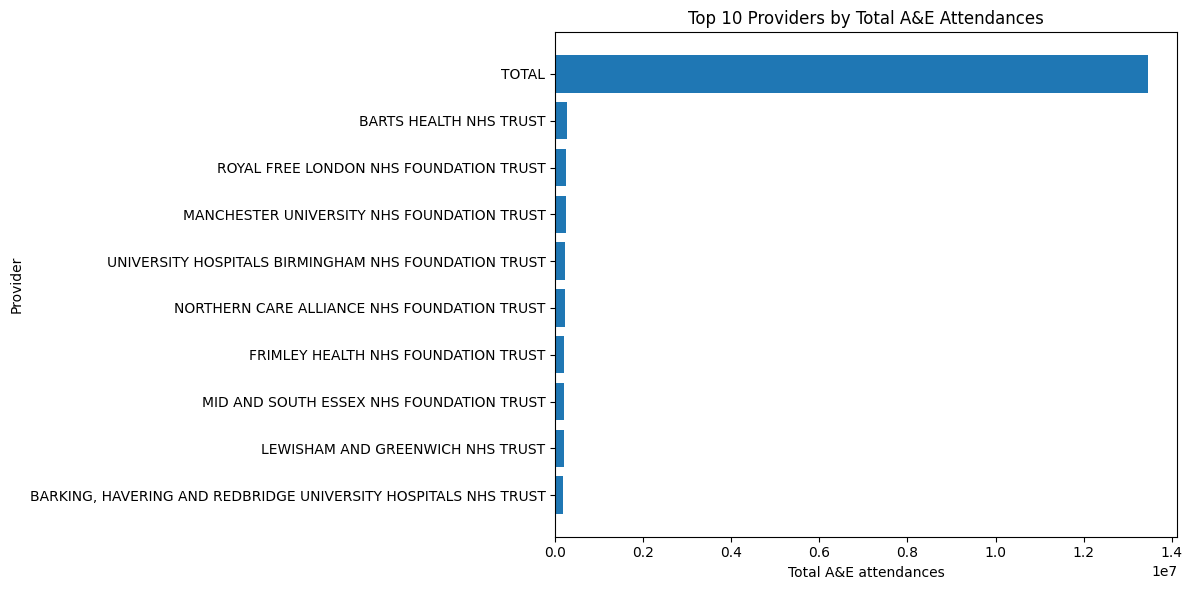

In [104]:
# Chart 1: Top 10 providers by total A&E attendances

plt.figure(figsize=(12, 6))

plt.barh(
    top_attendance["org_name"],
    top_attendance["total_ae_attendances"]
)

plt.xlabel("Total A&E attendances")
plt.ylabel("Provider")
plt.title("Top 10 Providers by Total A&E Attendances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


This chart shows which providers recorded the highest A&E attendance volumes across the six-month period. High attendance volume may indicate demand pressure and can help identify organisations that require closer operational review.

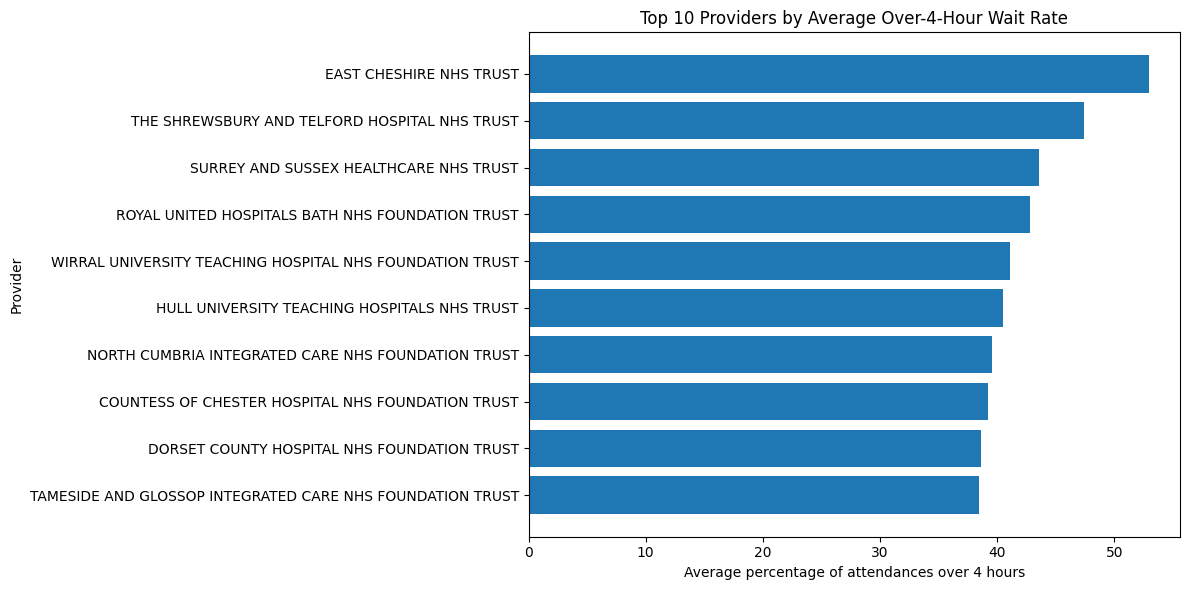

In [105]:
# Chart 2: Top 10 providers by average over-4-hour wait rate

plt.figure(figsize=(12, 6))

plt.barh(
    top_over_4hr_rate["org_name"],
    top_over_4hr_rate["over_4hr_rate"]
)

plt.xlabel("Average percentage of attendances over 4 hours")
plt.ylabel("Provider")
plt.title("Top 10 Providers by Average Over-4-Hour Wait Rate")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This chart highlights providers with the highest average proportion of attendances waiting over 4 hours. This helps identify where waiting-time pressure appears most significant.

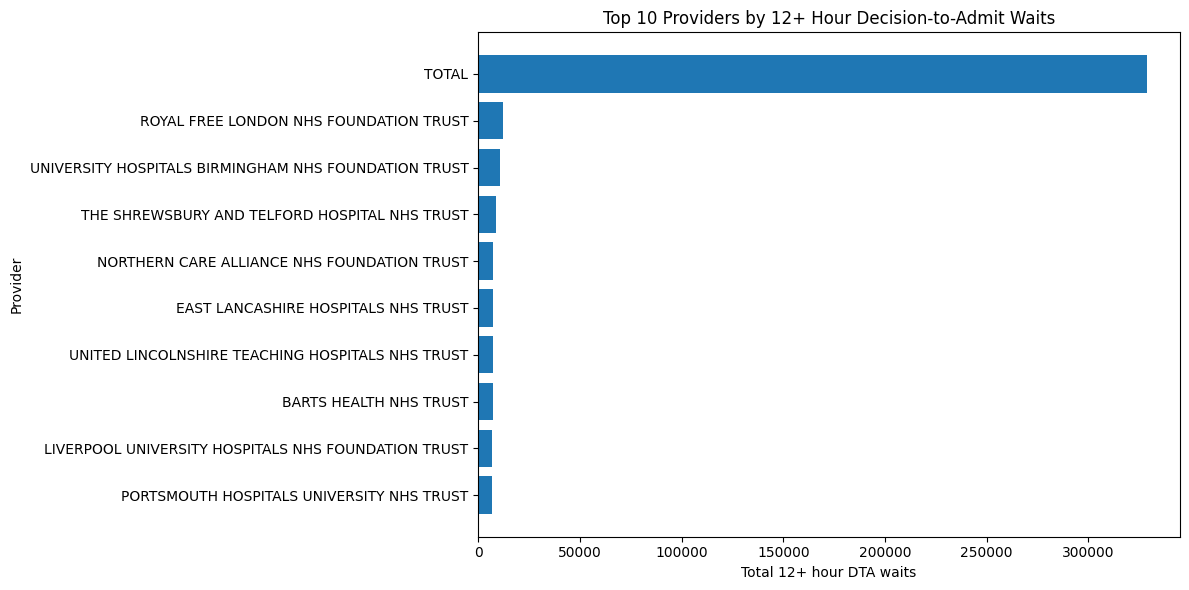

In [106]:
# Chart 3: Top 10 providers by 12+ hour waits after decision to admit

plt.figure(figsize=(12, 6))

plt.barh(
    top_12hr_dta["org_name"],
    top_12hr_dta["dta_12plus_waits"]
)

plt.xlabel("Total 12+ hour DTA waits")
plt.ylabel("Provider")
plt.title("Top 10 Providers by 12+ Hour Decision-to-Admit Waits")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This chart shows providers with the highest total number of 12+ hour waits after a decision to admit. These waits may point to wider admission, flow or bed-capacity pressures.

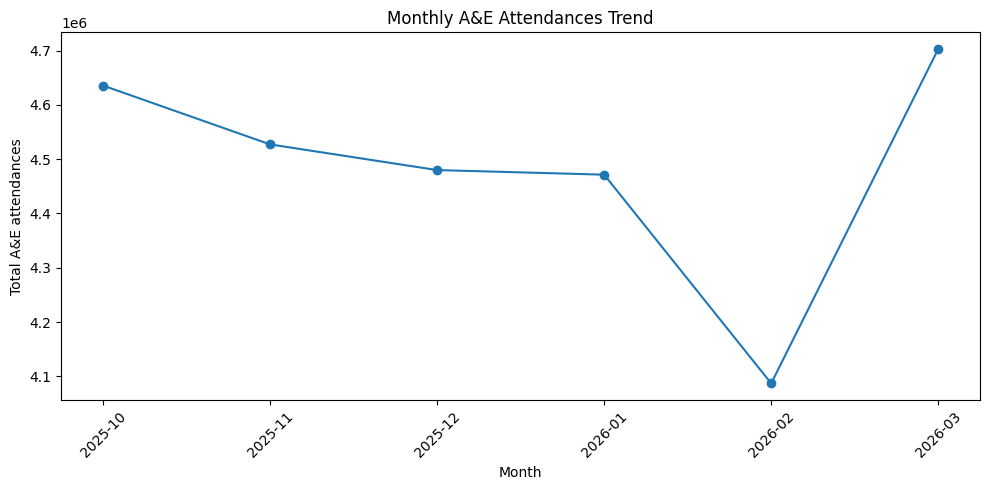

In [107]:
# Chart 4: Monthly total A&E attendances trend

monthly_trend = (
    ae.groupby("month")["total_ae_attendances"]
    .sum()
    .reset_index()
    .sort_values("month")
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_trend["month"],
    monthly_trend["total_ae_attendances"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Total A&E attendances")
plt.title("Monthly A&E Attendances Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This line chart shows how total A&E attendances changed month by month. Trend analysis helps identify whether demand is rising, falling or remaining stable over time.

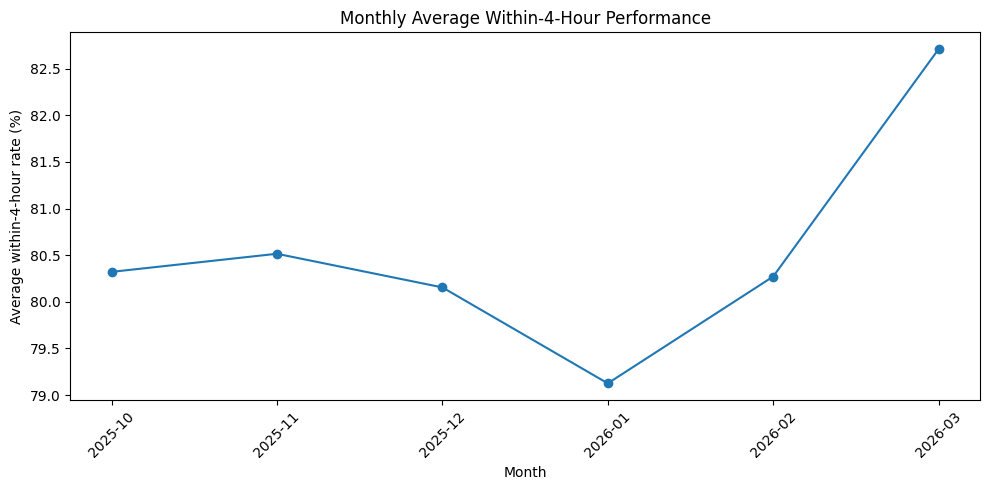

In [108]:
# Chart 5: Monthly average within-4-hour performance

monthly_performance = (
    ae.groupby("month")["within_4hr_rate"]
    .mean()
    .reset_index()
    .sort_values("month")
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_performance["month"],
    monthly_performance["within_4hr_rate"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Average within-4-hour rate (%)")
plt.title("Monthly Average Within-4-Hour Performance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This chart shows the average within-4-hour performance across providers for each month. It gives a high-level view of whether waiting-time performance is improving or worsening over the period analysed.

## 8. Identifying pressure points

This step highlights the organisations or areas with the highest levels of A&E pressure, such as high attendance volumes, long waits or lower performance against key measures.

This table summarises each provider across the full six-month period. It combines activity, waiting-time and admission measures so that providers can be compared more clearly.

In [109]:
# Create provider-level summary across the six-month period

provider_pressure = (
    ae.groupby("org_name")
    .agg(
        total_attendances=("total_ae_attendances", "sum"),
        total_over_4hr_waits=("total_attendances_over_4hrs", "sum"),
        avg_over_4hr_rate=("over_4hr_rate", "mean"),
        avg_within_4hr_rate=("within_4hr_rate", "mean"),
        total_emergency_admissions=("total_emergency_admissions_via_ae", "sum"),
        total_dta_12plus_waits=("dta_12plus_waits", "sum"),
        avg_admission_rate=("admission_rate", "mean")
    )
    .reset_index()
)

provider_pressure.head()

,org_name,total_attendances,total_over_4hr_waits,avg_over_4hr_rate,avg_within_4hr_rate,total_emergency_admissions,total_dta_12plus_waits,avg_admission_rate
0,AIREDALE NHS FOUNDATION TRUST,36914,14054,38.134444,61.865556,9378,1592,25.415439
1,ALDER HEY CHILDREN'S NHS FOUNDATION TRUST,38202,6045,15.886011,84.113989,5601,0,14.709981
2,ASHFORD AND ST PETER'S HOSPITALS NHS FOUNDATIO...,61672,22507,36.537444,63.462556,17615,2232,28.606305
3,ASHFORD WALK-IN-CENTRE,14148,236,1.667302,98.332698,0,0,0.000000
4,ASSURA VERTIS URGENT CARE CENTRES (BIRMINGHAM),19766,0,0.000000,100.000000,0,0,0.000000


In [110]:
# Rank providers on different pressure indicators

provider_pressure["attendance_rank"] = provider_pressure["total_attendances"].rank(ascending=False)
provider_pressure["over_4hr_rate_rank"] = provider_pressure["avg_over_4hr_rate"].rank(ascending=False)
provider_pressure["dta_12plus_rank"] = provider_pressure["total_dta_12plus_waits"].rank(ascending=False)
provider_pressure["admission_rank"] = provider_pressure["total_emergency_admissions"].rank(ascending=False)

# Create a simple combined pressure score
# Lower score = higher pressure across the combined measures

provider_pressure["pressure_score"] = (
    provider_pressure["attendance_rank"] +
    provider_pressure["over_4hr_rate_rank"] +
    provider_pressure["dta_12plus_rank"] +
    provider_pressure["admission_rank"]
)

top_pressure_providers = (
    provider_pressure
    .sort_values("pressure_score")
    .head(10)
)

top_pressure_providers

,org_name,total_attendances,total_over_4hr_waits,avg_over_4hr_rate,avg_within_4hr_rate,total_emergency_admissions,total_dta_12plus_waits,avg_admission_rate,attendance_rank,over_4hr_rate_rank,dta_12plus_rank,admission_rank,pressure_score
176,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,225271,83732,37.210468,62.789532,64690,10511,28.718668,5.0,16.0,3.0,2.0,26.0
185,UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST,180652,66717,36.992219,63.007781,51710,5630,28.626436,11.0,18.0,15.0,4.0,48.0
111,NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST,213895,64209,30.037396,69.962604,48702,7370,22.791443,6.0,52.0,5.0,5.0,68.0
98,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,208334,65706,31.613660,68.386340,52341,5276,25.126432,8.0,43.0,18.0,3.0,72.0
114,NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST,143128,54011,37.748846,62.251154,27513,5225,19.263256,24.0,12.0,19.0,22.0,77.0
181,UNIVERSITY HOSPITALS OF LEICESTER NHS TRUST,147496,53719,36.426289,63.573711,41745,4416,28.334830,22.0,22.0,27.0,7.0,78.0
83,LIVERPOOL UNIVERSITY HOSPITALS NHS FOUNDATION ...,154633,50084,32.395095,67.604905,30499,6956,19.740269,18.0,39.0,9.0,16.0,82.0
171,TOTAL,13451843,3527095,26.247655,73.752345,2389008,328594,17.761796,1.0,81.0,1.0,1.0,84.0
183,UNIVERSITY HOSPITALS OF NORTH MIDLANDS NHS TRUST,139577,49070,35.196741,64.803259,28520,6523,20.471659,26.0,25.0,13.0,20.0,84.0
173,UNITED LINCOLNSHIRE TEACHING HOSPITALS NHS TRUST,129418,42331,32.823824,67.176176,29852,7232,23.083710,29.0,35.0,7.0,18.0,89.0


The pressure score is a simple portfolio measure created by combining provider rankings across attendances, over-4-hour waits, 12-hour DTA waits and emergency admissions. It is not an official NHS metric, but it helps identify providers that may warrant closer operational review.

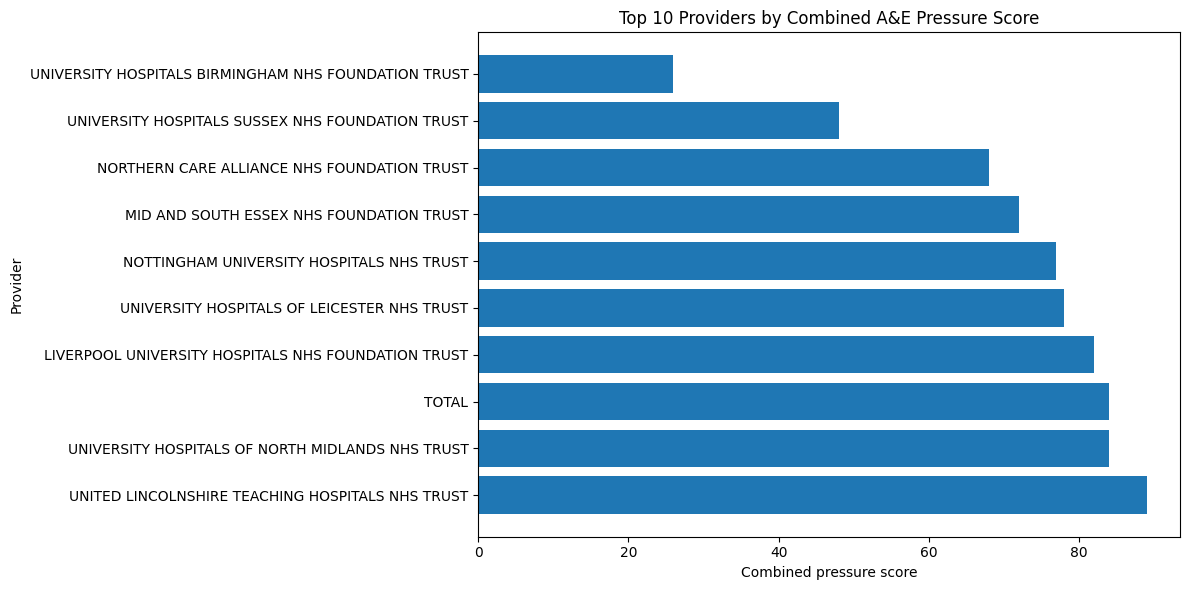

In [111]:
# Chart: Top 10 providers by combined pressure score

plt.figure(figsize=(12, 6))

plt.barh(
    top_pressure_providers["org_name"],
    top_pressure_providers["pressure_score"]
)

plt.xlabel("Combined pressure score")
plt.ylabel("Provider")
plt.title("Top 10 Providers by Combined A&E Pressure Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This chart shows the providers with the strongest combined pressure signals. A lower pressure score means the provider ranked highly across several pressure measures.

In [112]:
# Create a cleaner table for reporting

pressure_table = top_pressure_providers[[
    "org_name",
    "total_attendances",
    "avg_over_4hr_rate",
    "avg_within_4hr_rate",
    "total_emergency_admissions",
    "total_dta_12plus_waits",
    "pressure_score"
]].copy()

# Round percentage columns for readability

pressure_table["avg_over_4hr_rate"] = pressure_table["avg_over_4hr_rate"].round(1)
pressure_table["avg_within_4hr_rate"] = pressure_table["avg_within_4hr_rate"].round(1)
pressure_table["pressure_score"] = pressure_table["pressure_score"].round(1)

pressure_table

,org_name,total_attendances,avg_over_4hr_rate,avg_within_4hr_rate,total_emergency_admissions,total_dta_12plus_waits,pressure_score
176,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,225271,37.2,62.8,64690,10511,26.0
185,UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST,180652,37.0,63.0,51710,5630,48.0
111,NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST,213895,30.0,70.0,48702,7370,68.0
98,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,208334,31.6,68.4,52341,5276,72.0
114,NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST,143128,37.7,62.3,27513,5225,77.0
181,UNIVERSITY HOSPITALS OF LEICESTER NHS TRUST,147496,36.4,63.6,41745,4416,78.0
83,LIVERPOOL UNIVERSITY HOSPITALS NHS FOUNDATION ...,154633,32.4,67.6,30499,6956,82.0
171,TOTAL,13451843,26.2,73.8,2389008,328594,84.0
183,UNIVERSITY HOSPITALS OF NORTH MIDLANDS NHS TRUST,139577,35.2,64.8,28520,6523,84.0
173,UNITED LINCOLNSHIRE TEACHING HOSPITALS NHS TRUST,129418,32.8,67.2,29852,7232,89.0


This reporting table is easier to read than the raw output and could be used in a dashboard, management summary or portfolio report.

## 8A. Outlier Detection

In this section, I use simple outlier detection to identify providers with unusually high waiting-time or admission-pressure indicators. This helps highlight organisations that may require closer operational review.

For this portfolio project, I use a z-score approach. A z-score shows how far a provider is from the average. Providers with a z-score above 2 are flagged as potential outliers.

In [113]:
# 8A. Outlier Detection using z-scores

outlier_df = provider_pressure.copy()

# Function to calculate z-score
def calculate_z_score(series):
    return (series - series.mean()) / series.std()

# Create z-scores for key pressure indicators
outlier_df["over_4hr_rate_zscore"] = calculate_z_score(outlier_df["avg_over_4hr_rate"])
outlier_df["dta_12plus_zscore"] = calculate_z_score(outlier_df["total_dta_12plus_waits"])
outlier_df["admission_zscore"] = calculate_z_score(outlier_df["total_emergency_admissions"])
outlier_df["attendance_zscore"] = calculate_z_score(outlier_df["total_attendances"])

# Flag providers with unusually high pressure
outlier_df["high_waiting_time_outlier"] = outlier_df["over_4hr_rate_zscore"] > 2
outlier_df["high_dta_wait_outlier"] = outlier_df["dta_12plus_zscore"] > 2
outlier_df["high_admission_outlier"] = outlier_df["admission_zscore"] > 2
outlier_df["high_attendance_outlier"] = outlier_df["attendance_zscore"] > 2

# Create an overall outlier flag
outlier_df["any_pressure_outlier"] = (
    outlier_df["high_waiting_time_outlier"] |
    outlier_df["high_dta_wait_outlier"] |
    outlier_df["high_admission_outlier"] |
    outlier_df["high_attendance_outlier"]
)

# Display providers flagged as outliers
pressure_outliers = outlier_df[outlier_df["any_pressure_outlier"] == True].copy()

pressure_outliers[[
    "org_name",
    "total_attendances",
    "avg_over_4hr_rate",
    "total_dta_12plus_waits",
    "total_emergency_admissions",
    "over_4hr_rate_zscore",
    "dta_12plus_zscore",
    "admission_zscore",
    "attendance_zscore",
    "high_waiting_time_outlier",
    "high_dta_wait_outlier",
    "high_admission_outlier",
    "high_attendance_outlier"
]].sort_values("over_4hr_rate_zscore", ascending=False)

,org_name,total_attendances,avg_over_4hr_rate,total_dta_12plus_waits,total_emergency_admissions,over_4hr_rate_zscore,dta_12plus_zscore,admission_zscore,attendance_zscore,high_waiting_time_outlier,high_dta_wait_outlier,high_admission_outlier,high_attendance_outlier
40,EAST CHESHIRE NHS TRUST,26147,52.945875,2332,4780,2.321286,-0.040455,-0.112947,-0.113864,True,False,False,False
171,TOTAL,13451843,26.247655,328594,2389008,0.476663,14.036847,14.066893,14.079991,False,True,True,True


The outlier table highlights providers that sit unusually high compared with the wider dataset. These are not necessarily poor-performing organisations, but they may be useful starting points for further operational review because their pressure indicators are noticeably different from the average.

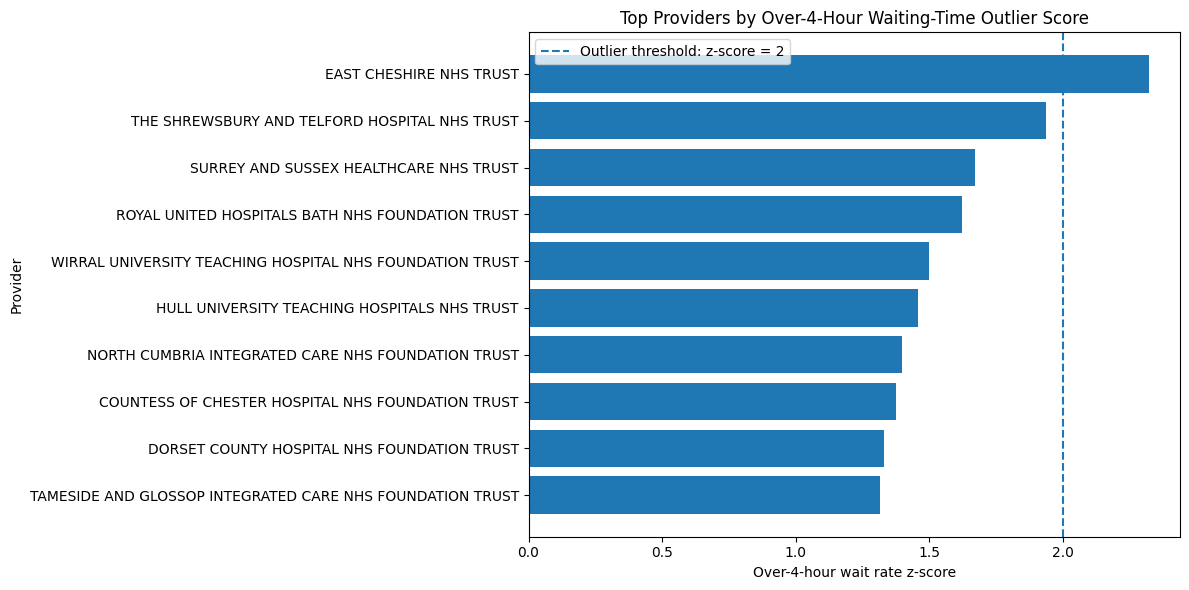

In [114]:
# Chart: Providers with unusually high over-4-hour waiting-time pressure

top_wait_outliers = (
    outlier_df
    .sort_values("over_4hr_rate_zscore", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_wait_outliers["org_name"],
    top_wait_outliers["over_4hr_rate_zscore"]
)

plt.axvline(2, linestyle="--", label="Outlier threshold: z-score = 2")

plt.xlabel("Over-4-hour wait rate z-score")
plt.ylabel("Provider")
plt.title("Top Providers by Over-4-Hour Waiting-Time Outlier Score")
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.show()

This chart shows which providers have the highest over-4-hour waiting-time z-scores. The dashed line represents the outlier threshold used in this analysis.

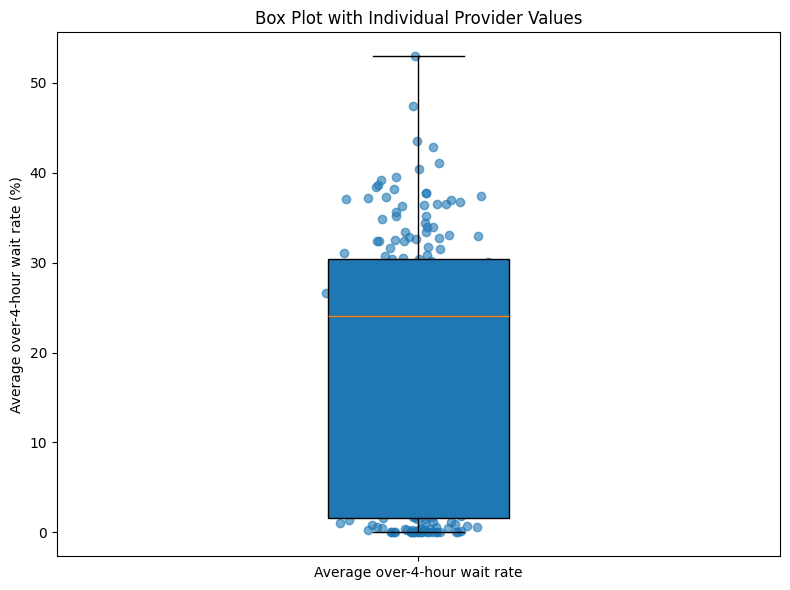

In [129]:
# Box plot: average over-4-hour wait rate



plt.figure(figsize=(8, 6))

data = outlier_df["avg_over_4hr_rate"].dropna()

# Create slight horizontal jitter so points do not sit directly on top of each other
x_jitter = np.random.normal(loc=1, scale=0.04, size=len(data))

# Draw box plot
plt.boxplot(
    data,
    positions=[1],
    widths=0.25,
    patch_artist=True,
    showfliers=False
)

# Overlay individual data points
plt.scatter(
    x_jitter,
    data,
    alpha=0.6
)

plt.xticks([1], ["Average over-4-hour wait rate"])
plt.ylabel("Average over-4-hour wait rate (%)")
plt.title("Box Plot with Individual Provider Values")
plt.tight_layout()
plt.show()

This box plot shows the distribution of average over-4-hour wait rates across providers. Points beyond the whiskers can be interpreted as unusually high or low values and may warrant closer review.

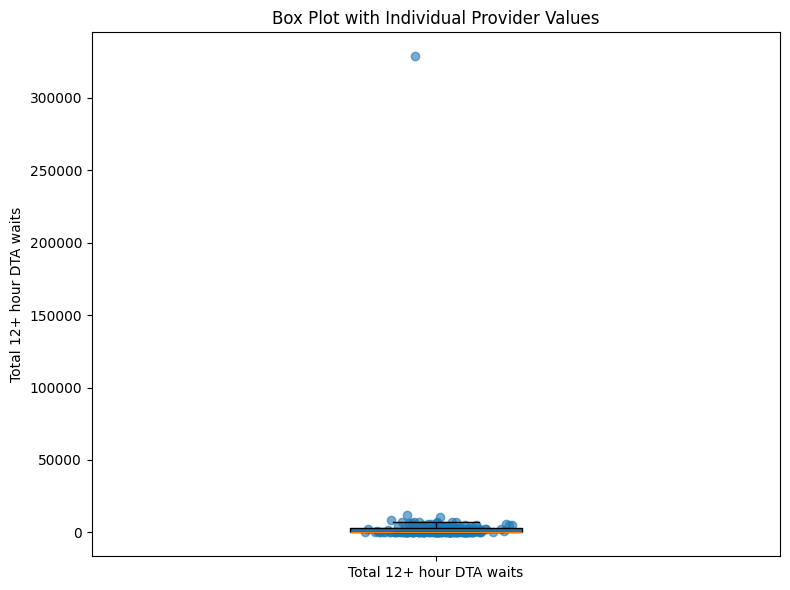

In [128]:
# Box plot: total 12+ hour DTA waits


plt.figure(figsize=(8, 6))

data = outlier_df["total_dta_12plus_waits"].dropna()

x_jitter = np.random.normal(loc=1, scale=0.04, size=len(data))

plt.boxplot(
    data,
    positions=[1],
    widths=0.25,
    patch_artist=True,
    showfliers=False
)

plt.scatter(
    x_jitter,
    data,
    alpha=0.6
)

plt.xticks([1], ["Total 12+ hour DTA waits"])
plt.ylabel("Total 12+ hour DTA waits")
plt.title("Box Plot with Individual Provider Values")
plt.tight_layout()
plt.show()

This box plot shows the distribution of 12+ hour waits after a decision to admit. Providers beyond the whiskers may represent unusual admission-flow or bed-capacity pressure.

## 8B. Provider Segmentation

In this section, I segment providers into simple pressure groups using demand and waiting-time performance.

This helps separate providers with high demand from providers with disproportionate waiting-time pressure. The aim is to create a more practical business-style view of the data rather than only ranking providers.

In [117]:
# 8B. Provider Segmentation

segment_df = provider_pressure.copy()

# Define median thresholds
attendance_median = segment_df["total_attendances"].median()
wait_rate_median = segment_df["avg_over_4hr_rate"].median()

# Function to assign segment
def assign_pressure_segment(row):
    if row["total_attendances"] >= attendance_median and row["avg_over_4hr_rate"] >= wait_rate_median:
        return "High demand / High wait pressure"
    elif row["total_attendances"] >= attendance_median and row["avg_over_4hr_rate"] < wait_rate_median:
        return "High demand / Lower wait pressure"
    elif row["total_attendances"] < attendance_median and row["avg_over_4hr_rate"] >= wait_rate_median:
        return "Lower demand / High wait pressure"
    else:
        return "Lower demand / Lower wait pressure"

# Apply segmentation
segment_df["pressure_segment"] = segment_df.apply(assign_pressure_segment, axis=1)

# View segment counts
segment_counts = (
    segment_df["pressure_segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["pressure_segment", "number_of_providers"]

segment_counts

,pressure_segment,number_of_providers
0,Lower demand / Lower wait pressure,79
1,High demand / High wait pressure,74
2,High demand / Lower wait pressure,27
3,Lower demand / High wait pressure,21


In [118]:
# Summary statistics by pressure segment

segment_summary = (
    segment_df.groupby("pressure_segment")
    .agg(
        providers=("org_name", "count"),
        avg_total_attendances=("total_attendances", "mean"),
        avg_over_4hr_rate=("avg_over_4hr_rate", "mean"),
        avg_within_4hr_rate=("avg_within_4hr_rate", "mean"),
        avg_dta_12plus_waits=("total_dta_12plus_waits", "mean"),
        avg_emergency_admissions=("total_emergency_admissions", "mean")
    )
    .reset_index()
)

# Round for readability
segment_summary["avg_total_attendances"] = segment_summary["avg_total_attendances"].round(0)
segment_summary["avg_over_4hr_rate"] = segment_summary["avg_over_4hr_rate"].round(1)
segment_summary["avg_within_4hr_rate"] = segment_summary["avg_within_4hr_rate"].round(1)
segment_summary["avg_dta_12plus_waits"] = segment_summary["avg_dta_12plus_waits"].round(0)
segment_summary["avg_emergency_admissions"] = segment_summary["avg_emergency_admissions"].round(0)

segment_summary

,pressure_segment,providers,avg_total_attendances,avg_over_4hr_rate,avg_within_4hr_rate,avg_dta_12plus_waits,avg_emergency_admissions
0,High demand / High wait pressure,74,294780.0,31.4,68.6,7749.0,54932.0
1,High demand / Lower wait pressure,27,112556.0,18.5,81.5,1917.0,16954.0
2,Lower demand / High wait pressure,21,45494.0,33.1,66.9,1413.0,11006.0
3,Lower demand / Lower wait pressure,79,13868.0,2.4,97.6,30.0,306.0


In [119]:
# Display segment counts and segment summary clearly

print("Segment counts:")
display(segment_counts)

print("Segment summary:")
display(segment_summary)

Segment counts:


,pressure_segment,number_of_providers
0,Lower demand / Lower wait pressure,79
1,High demand / High wait pressure,74
2,High demand / Lower wait pressure,27
3,Lower demand / High wait pressure,21


Segment summary:


,pressure_segment,providers,avg_total_attendances,avg_over_4hr_rate,avg_within_4hr_rate,avg_dta_12plus_waits,avg_emergency_admissions
0,High demand / High wait pressure,74,294780.0,31.4,68.6,7749.0,54932.0
1,High demand / Lower wait pressure,27,112556.0,18.5,81.5,1917.0,16954.0
2,Lower demand / High wait pressure,21,45494.0,33.1,66.9,1413.0,11006.0
3,Lower demand / Lower wait pressure,79,13868.0,2.4,97.6,30.0,306.0


In [120]:
# 8B. Provider Segmentation

segment_df = provider_pressure.copy()

# Define median thresholds
attendance_median = segment_df["total_attendances"].median()
wait_rate_median = segment_df["avg_over_4hr_rate"].median()

# Function to assign segment
def assign_pressure_segment(row):
    if row["total_attendances"] >= attendance_median and row["avg_over_4hr_rate"] >= wait_rate_median:
        return "High demand / High wait pressure"
    elif row["total_attendances"] >= attendance_median and row["avg_over_4hr_rate"] < wait_rate_median:
        return "High demand / Lower wait pressure"
    elif row["total_attendances"] < attendance_median and row["avg_over_4hr_rate"] >= wait_rate_median:
        return "Lower demand / High wait pressure"
    else:
        return "Lower demand / Lower wait pressure"

# Apply segmentation
segment_df["pressure_segment"] = segment_df.apply(assign_pressure_segment, axis=1)

# View segment counts
segment_counts = (
    segment_df["pressure_segment"]
    .value_counts()
    .reset_index()
)

segment_counts.columns = ["pressure_segment", "number_of_providers"]

segment_counts

,pressure_segment,number_of_providers
0,Lower demand / Lower wait pressure,79
1,High demand / High wait pressure,74
2,High demand / Lower wait pressure,27
3,Lower demand / High wait pressure,21


The segmentation groups providers into four categories based on total demand and average over-4-hour waiting-time pressure. This makes the analysis easier to interpret for decision-makers.

In [121]:
# Summary statistics by pressure segment

segment_summary = (
    segment_df.groupby("pressure_segment")
    .agg(
        providers=("org_name", "count"),
        avg_total_attendances=("total_attendances", "mean"),
        avg_over_4hr_rate=("avg_over_4hr_rate", "mean"),
        avg_within_4hr_rate=("avg_within_4hr_rate", "mean"),
        avg_dta_12plus_waits=("total_dta_12plus_waits", "mean"),
        avg_emergency_admissions=("total_emergency_admissions", "mean")
    )
    .reset_index()
)

# Round for readability
segment_summary["avg_total_attendances"] = segment_summary["avg_total_attendances"].round(0)
segment_summary["avg_over_4hr_rate"] = segment_summary["avg_over_4hr_rate"].round(1)
segment_summary["avg_within_4hr_rate"] = segment_summary["avg_within_4hr_rate"].round(1)
segment_summary["avg_dta_12plus_waits"] = segment_summary["avg_dta_12plus_waits"].round(0)
segment_summary["avg_emergency_admissions"] = segment_summary["avg_emergency_admissions"].round(0)

segment_summary

,pressure_segment,providers,avg_total_attendances,avg_over_4hr_rate,avg_within_4hr_rate,avg_dta_12plus_waits,avg_emergency_admissions
0,High demand / High wait pressure,74,294780.0,31.4,68.6,7749.0,54932.0
1,High demand / Lower wait pressure,27,112556.0,18.5,81.5,1917.0,16954.0
2,Lower demand / High wait pressure,21,45494.0,33.1,66.9,1413.0,11006.0
3,Lower demand / Lower wait pressure,79,13868.0,2.4,97.6,30.0,306.0


This table summarises the average pressure profile for each segment. It helps show how demand, waiting-time pressure, admissions and long waits differ between provider groups.

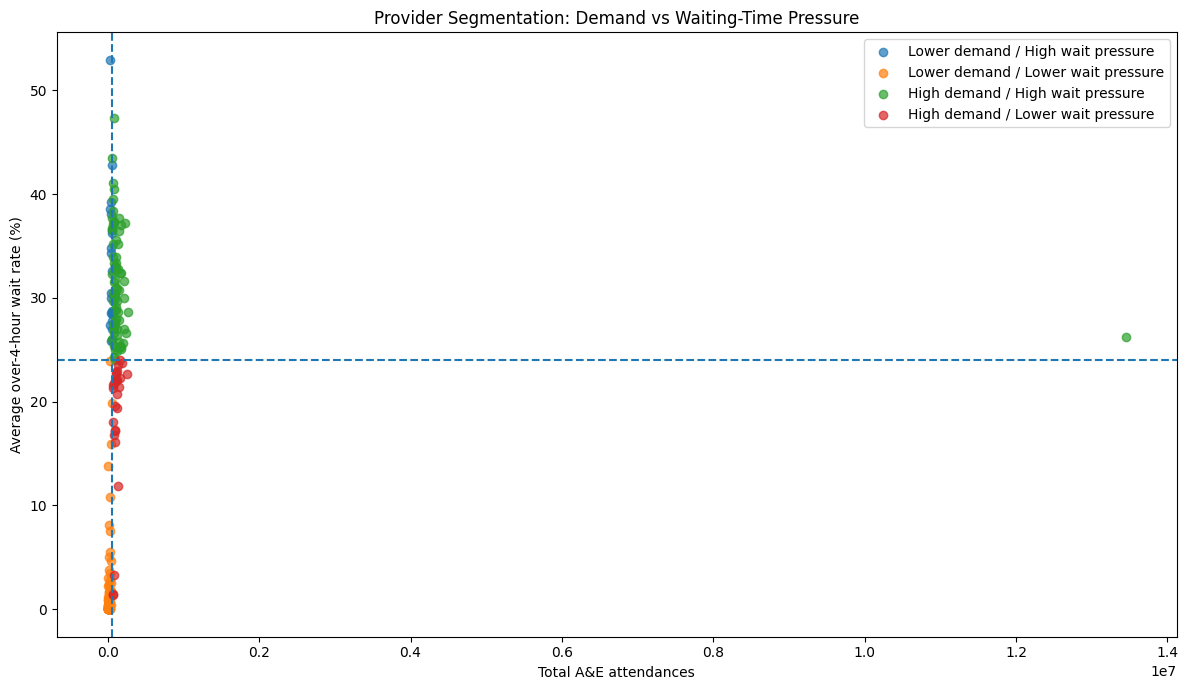

In [122]:
# Scatter plot: demand vs waiting-time pressure

plt.figure(figsize=(12, 7))

segments = segment_df["pressure_segment"].unique()

for segment in segments:
    subset = segment_df[segment_df["pressure_segment"] == segment]
    plt.scatter(
        subset["total_attendances"],
        subset["avg_over_4hr_rate"],
        label=segment,
        alpha=0.7
    )

plt.axvline(attendance_median, linestyle="--")
plt.axhline(wait_rate_median, linestyle="--")

plt.xlabel("Total A&E attendances")
plt.ylabel("Average over-4-hour wait rate (%)")
plt.title("Provider Segmentation: Demand vs Waiting-Time Pressure")
plt.legend()
plt.tight_layout()
plt.show()

This scatter plot compares provider demand against waiting-time pressure. The dashed lines show the median thresholds used to create the four pressure segments.

In [123]:
# Providers in the High demand / High wait pressure segment

high_pressure_segment = (
    segment_df[segment_df["pressure_segment"] == "High demand / High wait pressure"]
    .sort_values("pressure_score")
)

high_pressure_segment[[
    "org_name",
    "total_attendances",
    "avg_over_4hr_rate",
    "avg_within_4hr_rate",
    "total_dta_12plus_waits",
    "total_emergency_admissions",
    "pressure_score",
    "pressure_segment"
]].head(15)

,org_name,total_attendances,avg_over_4hr_rate,avg_within_4hr_rate,total_dta_12plus_waits,total_emergency_admissions,pressure_score,pressure_segment
176,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,225271,37.210468,62.789532,10511,64690,26.0,High demand / High wait pressure
185,UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST,180652,36.992219,63.007781,5630,51710,48.0,High demand / High wait pressure
111,NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST,213895,30.037396,69.962604,7370,48702,68.0,High demand / High wait pressure
98,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,208334,31.613660,68.386340,5276,52341,72.0,High demand / High wait pressure
114,NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST,143128,37.748846,62.251154,5225,27513,77.0,High demand / High wait pressure
181,UNIVERSITY HOSPITALS OF LEICESTER NHS TRUST,147496,36.426289,63.573711,4416,41745,78.0,High demand / High wait pressure
83,LIVERPOOL UNIVERSITY HOSPITALS NHS FOUNDATION ...,154633,32.395095,67.604905,6956,30499,82.0,High demand / High wait pressure
171,TOTAL,13451843,26.247655,73.752345,328594,2389008,84.0,High demand / High wait pressure
183,UNIVERSITY HOSPITALS OF NORTH MIDLANDS NHS TRUST,139577,35.196741,64.803259,6523,28520,84.0,High demand / High wait pressure
173,UNITED LINCOLNSHIRE TEACHING HOSPITALS NHS TRUST,129418,32.823824,67.176176,7232,29852,89.0,High demand / High wait pressure


The providers in the high demand / high wait pressure segment may be important candidates for deeper operational review because they combine high activity levels with higher waiting-time pressure.

## 9. Key insights

I summarise the main findings from the analysis in plain English, focusing on what the data suggests and why it may matter.

In [124]:
# Key insight tables for reporting

# Top providers by total attendances
insight_top_attendance = top_attendance.head(5)

# Top providers by over-4-hour wait rate
insight_top_wait_rate = top_over_4hr_rate.head(5)

# Top providers by 12+ hour DTA waits
insight_top_dta = top_12hr_dta.head(5)

# Top providers by combined pressure score
insight_top_pressure = top_pressure_providers.head(5)

# Providers flagged as pressure outliers
insight_outliers = pressure_outliers[[
    "org_name",
    "total_attendances",
    "avg_over_4hr_rate",
    "total_dta_12plus_waits",
    "total_emergency_admissions",
    "any_pressure_outlier"
]].copy()

print("Top attendance providers:")
display(insight_top_attendance)

print("Top over-4-hour wait rate providers:")
display(insight_top_wait_rate)

print("Top 12+ hour DTA wait providers:")
display(insight_top_dta)

print("Top combined pressure providers:")
display(insight_top_pressure)

print("Pressure outliers:")
display(insight_outliers.head(10))




Top attendance providers:


,org_name,total_ae_attendances
0,TOTAL,13451843
1,BARTS HEALTH NHS TRUST,267357
2,ROYAL FREE LONDON NHS FOUNDATION TRUST,256846
3,MANCHESTER UNIVERSITY NHS FOUNDATION TRUST,242258
4,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,225271


Top over-4-hour wait rate providers:


,org_name,over_4hr_rate
0,EAST CHESHIRE NHS TRUST,52.945875
1,THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST,47.370302
2,SURREY AND SUSSEX HEALTHCARE NHS TRUST,43.528248
3,ROYAL UNITED HOSPITALS BATH NHS FOUNDATION TRUST,42.831368
4,WIRRAL UNIVERSITY TEACHING HOSPITAL NHS FOUNDA...,41.050289


Top 12+ hour DTA wait providers:


,org_name,dta_12plus_waits
0,TOTAL,328594
1,ROYAL FREE LONDON NHS FOUNDATION TRUST,12244
2,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,10511
3,THE SHREWSBURY AND TELFORD HOSPITAL NHS TRUST,8641
4,NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST,7370


Top combined pressure providers:


,org_name,total_attendances,total_over_4hr_waits,avg_over_4hr_rate,avg_within_4hr_rate,total_emergency_admissions,total_dta_12plus_waits,avg_admission_rate,attendance_rank,over_4hr_rate_rank,dta_12plus_rank,admission_rank,pressure_score
176,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,225271,83732,37.210468,62.789532,64690,10511,28.718668,5.0,16.0,3.0,2.0,26.0
185,UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST,180652,66717,36.992219,63.007781,51710,5630,28.626436,11.0,18.0,15.0,4.0,48.0
111,NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST,213895,64209,30.037396,69.962604,48702,7370,22.791443,6.0,52.0,5.0,5.0,68.0
98,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,208334,65706,31.613660,68.386340,52341,5276,25.126432,8.0,43.0,18.0,3.0,72.0
114,NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST,143128,54011,37.748846,62.251154,27513,5225,19.263256,24.0,12.0,19.0,22.0,77.0


Pressure outliers:


,org_name,total_attendances,avg_over_4hr_rate,total_dta_12plus_waits,total_emergency_admissions,any_pressure_outlier
40,EAST CHESHIRE NHS TRUST,26147,52.945875,2332,4780,True
171,TOTAL,13451843,26.247655,328594,2389008,True


In [125]:
# Display segment counts and segment summary clearly

print("Segment counts:")
display(segment_counts)

print("Segment summary:")
display(segment_summary)

Segment counts:


,pressure_segment,number_of_providers
0,Lower demand / Lower wait pressure,79
1,High demand / High wait pressure,74
2,High demand / Lower wait pressure,27
3,Lower demand / High wait pressure,21


Segment summary:


,pressure_segment,providers,avg_total_attendances,avg_over_4hr_rate,avg_within_4hr_rate,avg_dta_12plus_waits,avg_emergency_admissions
0,High demand / High wait pressure,74,294780.0,31.4,68.6,7749.0,54932.0
1,High demand / Lower wait pressure,27,112556.0,18.5,81.5,1917.0,16954.0
2,Lower demand / High wait pressure,21,45494.0,33.1,66.9,1413.0,11006.0
3,Lower demand / Lower wait pressure,79,13868.0,2.4,97.6,30.0,306.0


## 10. Recommendations

Based on the findings, I suggest practical actions that could help decision-makers investigate pressure points, improve reporting or focus operational support.

### Recommendation 1: Prioritise providers with combined pressure signals

Providers that rank highly across attendance volume, over-4-hour waits, 12-hour DTA waits and emergency admissions should be prioritised for further review. These organisations may be experiencing pressure across multiple parts of the urgent and emergency care pathway.

A useful next step would be to review whether the pressure is linked to demand, admission flow, bed availability, staffing, triage capacity or discharge delays.


### Recommendation 2: Review high demand / high wait pressure providers

The segmentation analysis identifies providers that have both high attendance volumes and high waiting-time pressure. This group may need the closest operational review because demand pressure and waiting-time pressure are occurring together.

These providers could benefit from a deeper review of patient flow, streaming pathways, Same Day Emergency Care use, escalation processes and capacity planning.


In [126]:
# Priority providers for operational review

priority_providers = high_pressure_segment[[
    "org_name",
    "total_attendances",
    "avg_over_4hr_rate",
    "avg_within_4hr_rate",
    "total_dta_12plus_waits",
    "total_emergency_admissions",
    "pressure_score",
    "pressure_segment"
]].head(10)

priority_providers

,org_name,total_attendances,avg_over_4hr_rate,avg_within_4hr_rate,total_dta_12plus_waits,total_emergency_admissions,pressure_score,pressure_segment
176,UNIVERSITY HOSPITALS BIRMINGHAM NHS FOUNDATION...,225271,37.210468,62.789532,10511,64690,26.0,High demand / High wait pressure
185,UNIVERSITY HOSPITALS SUSSEX NHS FOUNDATION TRUST,180652,36.992219,63.007781,5630,51710,48.0,High demand / High wait pressure
111,NORTHERN CARE ALLIANCE NHS FOUNDATION TRUST,213895,30.037396,69.962604,7370,48702,68.0,High demand / High wait pressure
98,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,208334,31.613660,68.386340,5276,52341,72.0,High demand / High wait pressure
114,NOTTINGHAM UNIVERSITY HOSPITALS NHS TRUST,143128,37.748846,62.251154,5225,27513,77.0,High demand / High wait pressure
181,UNIVERSITY HOSPITALS OF LEICESTER NHS TRUST,147496,36.426289,63.573711,4416,41745,78.0,High demand / High wait pressure
83,LIVERPOOL UNIVERSITY HOSPITALS NHS FOUNDATION ...,154633,32.395095,67.604905,6956,30499,82.0,High demand / High wait pressure
171,TOTAL,13451843,26.247655,73.752345,328594,2389008,84.0,High demand / High wait pressure
183,UNIVERSITY HOSPITALS OF NORTH MIDLANDS NHS TRUST,139577,35.196741,64.803259,6523,28520,84.0,High demand / High wait pressure
173,UNITED LINCOLNSHIRE TEACHING HOSPITALS NHS TRUST,129418,32.823824,67.176176,7232,29852,89.0,High demand / High wait pressure


This table identifies a priority group of providers for further operational review based on combined pressure score and segmentation results.

### Recommendation 3: Investigate outlier providers separately

Outlier providers should be reviewed separately because their pressure indicators are unusually high compared with the wider dataset. These providers may have specific local factors that explain the pattern, such as specialist pathways, regional demand, capacity constraints or data-reporting differences.

Outlier detection should be treated as a prompt for further investigation rather than a final judgement on performance.

In [127]:
# Outlier providers for further review

outlier_review = pressure_outliers[[
    "org_name",
    "total_attendances",
    "avg_over_4hr_rate",
    "total_dta_12plus_waits",
    "total_emergency_admissions",
    "over_4hr_rate_zscore",
    "dta_12plus_zscore",
    "admission_zscore",
    "attendance_zscore"
]].copy()

outlier_review = outlier_review.sort_values(
    ["over_4hr_rate_zscore", "dta_12plus_zscore", "admission_zscore"],
    ascending=False
)

outlier_review.head(10)

,org_name,total_attendances,avg_over_4hr_rate,total_dta_12plus_waits,total_emergency_admissions,over_4hr_rate_zscore,dta_12plus_zscore,admission_zscore,attendance_zscore
40,EAST CHESHIRE NHS TRUST,26147,52.945875,2332,4780,2.321286,-0.040455,-0.112947,-0.113864
171,TOTAL,13451843,26.247655,328594,2389008,0.476663,14.036847,14.066893,14.079991


### Recommendation 4: Monitor monthly trends

The monthly trend analysis should be used to monitor whether pressure is increasing, decreasing or remaining stable over time. A single month may not show the full picture, so future work should add more months of data to identify seasonal pressure and longer-term changes.

This would make the dashboard more useful for regular reporting and early warning.

### Recommendation 5: Build this into a repeatable dashboard

This analysis could be developed into a repeatable dashboard that updates each month when new public data becomes available. This would allow users to track provider pressure, identify emerging outliers and compare organisations over time.

A future version could include regional filters, provider-level drilldowns, trend alerts and clearer separation between demand pressure, waiting-time pressure and admission-flow pressure.

### Summary of recommendations

The analysis suggests that operational review should focus on providers with repeated pressure across several indicators, especially those in the high demand / high wait pressure segment. Outlier providers should also be reviewed to understand whether their results reflect genuine operational pressure, local service differences or reporting factors.

Overall, the project shows how public healthcare data can be cleaned, transformed and analysed to support practical decision-making.

## 11. Portfolio summary

This project demonstrates how public healthcare data can be cleaned, analysed and presented in a way that supports business analysis, operational insight and evidence-based decision-making.

### Skills demonstrated

- Cleaning and combining multiple CSV files
- Preparing public healthcare data for analysis
- Creating operational KPIs
- Ranking and benchmarking providers
- Visualising trends and pressure indicators
- Detecting outliers using z-scores
- Segmenting providers into pressure groups
- Translating data into plain-English insights
- Producing practical recommendations for decision-making